# Social media — causal effect of boosting on donation referrals (CRISP-DM, Phases 1–6)

**Research question:** Does paying to boost a social media post *causally* increase the
probability that the post generates at least one donation referral (`has_referred_gift`)?

**Method:** T-Learner (meta-learner causal inference) using two scikit-learn Pipelines:
one fit on the control group (unboosted posts, n ≈ 685) and one on the treated group
(boosted posts, n ≈ 127). A propensity score model provides overlap diagnostics.

**This contrasts with** `social_media_engagement_increase.ipynb`, which uses a purely
predictive approach. This notebook explicitly estimates a causal treatment effect.

Run cells top-to-bottom. Each phase builds on the previous.

## Phase 1 — Business understanding

### Business problem
The nonprofit uses paid post boosting (Facebook/Instagram Ads) to amplify content reach.
Boosting costs money (`boost_budget_php`, typically ₱1,000–₱5,000 per post). The question
is whether boosting **causally** increases the chance that a post results in a donation
referral — not just whether boosted posts happen to correlate with more referrals.

### Why causal, not predictive
A predictive model of `has_referred_gift ~ is_boosted + features` would produce accurate
forecasts on average, but it cannot distinguish two very different stories:

1. **Genuine effect:** Boosting causes more referrals by reaching new audiences who then donate.
2. **Selection bias:** Staff choose to boost posts that are already expected to perform well
   (e.g. compelling campaign posts near a fundraising deadline). Those posts would have
   generated more referrals anyway, even without boosting.

A simple regression of `has_referred_gift` on `is_boosted` confounds these two stories.
We need to compare treated vs. control posts that have **similar pre-treatment characteristics**
— this is the causal identification problem.

### Approach: T-Learner (response surface method)
We use a T-Learner (two separate outcome models):
- **Control model `mu0(X)`:** Fit on unboosted posts → predicts P(gift | X, boost=0)
- **Treatment model `mu1(X)`:** Fit on boosted posts → predicts P(gift | X, boost=1)
- **Individual Treatment Effect (ITE):** `mu1(X) - mu0(X)` for any post with features X
- **Average Treatment Effect (ATE):** Mean ITE over all posts

A propensity model `e(X) = P(is_boosted | X)` is also fit (on all posts) for overlap
diagnostics — we check that treated and control groups share common covariate support.

### Treatment and outcome
- **Treatment:** `is_boosted` (binary: 1 = boosted, 0 = organic)
- **Outcome:** `has_referred_gift = (donation_referrals > 0)` (binary: 1 = any donation referral)

### Approach: Predictive vs. explanatory note
This is an **explanatory/causal** notebook, in contrast to the social engagement predictive
notebook. We aim to estimate a treatment effect, not just minimise prediction error.

### Key assumption
The T-Learner estimate is valid under **strong ignorability**: given the observed pre-treatment
covariates X, the potential outcomes Y(0) and Y(1) are independent of treatment assignment T.
This assumes **no unmeasured confounders** — factors that affect both the decision to boost
and the likelihood of a donation referral. This assumption cannot be verified from
observational data alone and should be stated in any reporting of results.

### Business decision this supports
"Given the planned content characteristics of a post, what is the estimated lift in
donation referral probability from spending money to boost it? Is the boost budget
likely to be worth the cost for *this specific post*?"

## Phase 2 — Data understanding

### Data source
Single table: `social_media_posts.csv` from `Dataset/lighthouse_csv_v7/`
- **Rows:** 812 posts
- **No joins required** — all features and the outcome are in one table.

### Treatment distribution
- Treated (boosted): ~127 posts (15.6%)
- Control (not boosted): ~685 posts (84.4%)

The treated group is small but sufficient for T-Learner estimation with regularised models.

### Outcome derivation
`has_referred_gift = (donation_referrals > 0).astype(int)`
- Based on `donation_referrals` column (count of donation referrals linked to each post)
- Approximately 64% positive (most posts are linked to at least one donation referral)

### Pre-treatment covariates (13 features — used as model inputs)
These are features known *before* the boosting decision and *before* any engagement occurs:

| Feature | Type | Notes |
|---------|------|-------|
| `caption_length` | numeric | Character count of caption |
| `num_hashtags` | numeric | Hashtag count |
| `follower_count_at_post` | numeric | Page followers at publish time |
| `post_hour` | numeric | Hour of publication (0–23) |
| `has_call_to_action` | binary | 1 if post has a CTA |
| `boost_budget_php` | numeric | 0 for control; planned budget for treated |
| `platform` | categorical | Facebook, Instagram, etc. |
| `post_type` | categorical | Photo, Video, Story, etc. |
| `media_type` | categorical | Image, Reel, Carousel, etc. |
| `content_topic` | categorical | Programme / campaign topic |
| `sentiment_tone` | categorical | Inspirational, Informational, etc. |
| `post_dow` | categorical | Day of week (derived from `created_at`) |
| `call_to_action_type` | categorical | CTA type; "None" when no CTA (structural) |

### Excluded columns (post-treatment mediators — "bad controls")
The following columns are **excluded** because they are caused by the treatment or occur
after treatment assignment, and including them would introduce post-treatment bias:

`impressions`, `reach`, `likes`, `comments`, `shares`, `saves`, `click_throughs`,
`video_views`, `engagement_rate`, `profile_visits`, `watch_time_seconds`,
`avg_view_duration_seconds`, `donation_referrals` (count version of outcome)

### Special handling
- `boost_budget_php`: NaN for all 685 control posts → fill with 0.0 (structural zero, not missing data)
- `call_to_action_type`: 319 missing → fill with "None" (structural: no CTA = no CTA type)
- `post_dow`: derived from `created_at` timestamp using `.dt.day_name()`

In [1]:
# Phase 2 — Load data and profile the causal analysis frame
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

# Locate the repo root (directory containing Dataset/)
_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError(
        "Could not find Dataset/ directory. Open Jupyter from the ml-pipelines root "
        "or a parent directory that contains Dataset/."
    )

DATA = _repo / "Dataset" / "lighthouse_csv_v7"
posts_raw = pd.read_csv(DATA / "social_media_posts.csv")

# Derive outcome and day-of-week feature
posts_raw["has_referred_gift"] = (posts_raw["donation_referrals"] > 0).astype(int)
posts_raw["post_dow"] = (
    pd.to_datetime(posts_raw["created_at"], errors="coerce")
    .dt.day_name()
    .fillna("Unknown")
)

print(f"Total posts: {len(posts_raw)}")
print(f"Treated (boosted):    {posts_raw['is_boosted'].sum():>4d}  ({posts_raw['is_boosted'].mean():.1%})")
print(f"Control (not boosted):{(posts_raw['is_boosted'] == 0).sum():>4d}  ({(posts_raw['is_boosted'] == 0).mean():.1%})")
print(f"Outcome positive:     {posts_raw['has_referred_gift'].sum():>4d}  ({posts_raw['has_referred_gift'].mean():.1%})")
print()

print("boost_budget_php missing by group:")
print(posts_raw.groupby("is_boosted")["boost_budget_php"].apply(lambda s: s.isna().sum()).rename("n_missing"))
print()

print("Pre-treatment covariate missing value counts:")
_pre_cols = [
    "caption_length", "num_hashtags", "follower_count_at_post", "post_hour",
    "has_call_to_action", "boost_budget_php",
    "platform", "post_type", "media_type", "content_topic",
    "sentiment_tone", "post_dow", "call_to_action_type",
]
display(posts_raw[_pre_cols].isnull().sum().rename("n_missing"))

Total posts: 812
Treated (boosted):     127  (15.6%)
Control (not boosted): 685  (84.4%)
Outcome positive:      522  (64.3%)

boost_budget_php missing by group:
is_boosted
False    685
True       0
Name: n_missing, dtype: int64

Pre-treatment covariate missing value counts:


caption_length              0
num_hashtags                0
follower_count_at_post      0
post_hour                   0
has_call_to_action          0
boost_budget_php          685
platform                    0
post_type                   0
media_type                  0
content_topic               0
sentiment_tone              0
post_dow                    0
call_to_action_type       319
Name: n_missing, dtype: int64

In [2]:
# Phase 2 — Outlier detection on numeric pre-treatment covariates (IQR method)
# Flagged rows are documented but NOT removed:
#   - Tree-based classifiers (RF, GBM) are robust to covariate outliers.
#   - boost_budget_php outliers = large campaigns; they are real and informative.
#   - Winsorising would distort the treatment dose variable for high-budget posts.

_numeric_check_cols = [
    "caption_length", "num_hashtags", "follower_count_at_post",
    "post_hour", "boost_budget_php",
]

# Use the full posts frame (before treatment-group split)
_check_frame = posts_raw.copy()
_check_frame["boost_budget_php"] = _check_frame["boost_budget_php"].fillna(0.0)

print(f"{'Column':<35} {'Q1':>8} {'Q3':>8} {'IQR':>8}  {'Fence [lo, hi]':<22}  {'n_outliers':>10}")
print("-" * 100)
for col in _numeric_check_cols:
    s = _check_frame[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((s < lo) | (s > hi)).sum())
    print(f"{col:<35} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f}  [{lo:>8.2f}, {hi:>8.2f}]  {n_out:>10d}")

print()
print("Decision: Leave all outliers.")
print("  boost_budget_php outliers = large campaigns (real signal, informative for dose effect).")
print("  follower_count outliers = high-reach accounts (retain for overlap analysis).")
print("  Tree models in Phase 4 are naturally robust to numeric outliers.")

Column                                    Q1       Q3      IQR  Fence [lo, hi]          n_outliers
----------------------------------------------------------------------------------------------------
caption_length                        121.00   152.00    31.00  [   74.50,   198.50]          44
num_hashtags                            1.00     3.00     2.00  [   -2.00,     6.00]           0
follower_count_at_post                916.00  1833.00   917.00  [ -459.50,  3208.50]           0
post_hour                               8.00    18.00    10.00  [   -7.00,    33.00]           0
boost_budget_php                        0.00     0.00     0.00  [    0.00,     0.00]         127

Decision: Leave all outliers.
  boost_budget_php outliers = large campaigns (real signal, informative for dose effect).
  follower_count outliers = high-reach accounts (retain for overlap analysis).
  Tree models in Phase 4 are naturally robust to numeric outliers.


## Phase 3 — Data preparation

### Feature set rationale
We use only **pre-treatment covariates** — features that are fixed before the boosting
decision is made and before any user engagement occurs.

**Why mediators are excluded ("bad controls"):**
Post-engagement metrics like `impressions`, `likes`, and `engagement_rate` occur *after*
boosting and are partially *caused by* boosting. Including them as covariates would introduce
post-treatment bias: the model would condition on the effect of the treatment while trying
to estimate the treatment effect, leading to biased ITE estimates.

### boost_budget_php fill rationale
For control posts (`is_boosted == 0`), `boost_budget_php` is structurally 0 — they received
no boost budget. The NaN values are not random missing data; they represent a structural zero.
We fill NaN with 0.0 before building X.

Including `boost_budget_php` as a covariate allows the T-Learner to condition on the budget
amount for treated posts (treatment dose) while control posts naturally receive 0.

### call_to_action_type fill rationale
When `has_call_to_action == 0`, `call_to_action_type` is structurally absent (no CTA = no type).
We fill missing values with `"None"` (a valid category), not `"Unknown"` (which implies a CTA
exists but the type was not recorded). This distinction matters for the one-hot encoder.

### Preprocessing
Shared across all three pipelines (control, treatment, propensity):
- **Numeric:** Median imputation + StandardScaler
- **Categorical:** Mode imputation + OneHotEncoder (handle_unknown="ignore")

In [3]:
# Phase 3 — Define feature sets and build X, T, Y arrays

CAUSAL_NUMERIC_FEATURES = [
    "caption_length",
    "num_hashtags",
    "follower_count_at_post",
    "post_hour",
    "has_call_to_action",
    "boost_budget_php",       # 0 for control (structural); dose for treated
]
CAUSAL_CATEGORICAL_FEATURES = [
    "platform",
    "post_type",
    "media_type",
    "content_topic",
    "sentiment_tone",
    "post_dow",               # derived from created_at in Phase 2 cell
    "call_to_action_type",   # "None" when no CTA (structural missing)
]
CAUSAL_FEATURE_COLUMNS = CAUSAL_NUMERIC_FEATURES + CAUSAL_CATEGORICAL_FEATURES

T_COL = "is_boosted"
Y_COL = "has_referred_gift"

df = posts_raw.copy()

# Fill structural missings
df["boost_budget_php"] = df["boost_budget_php"].fillna(0.0)
df["call_to_action_type"] = (
    df["call_to_action_type"].fillna("None").replace("", "None")
)
df["post_dow"] = df["post_dow"].fillna("Unknown")
df["is_boosted"] = df["is_boosted"].astype(int)
df["has_call_to_action"] = df["has_call_to_action"].fillna(0).astype(int)

for col in CAUSAL_CATEGORICAL_FEATURES:
    df[col] = df[col].astype("string").fillna("Unknown").replace("", "Unknown")
for col in CAUSAL_NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

X = df[CAUSAL_FEATURE_COLUMNS].copy()
T = df[T_COL].values.astype(int)
Y = df[Y_COL].values.astype(int)

print(f"X shape: {X.shape}")
print(f"Treated: {T.sum()}, Control: {(T == 0).sum()}")
print(f"Y positive: {Y.sum()} ({Y.mean():.1%})")
print()
print(f"Treated sub-sample — Y positive: {Y[T == 1].sum()} / {T.sum()} ({Y[T==1].mean():.1%})")
print(f"Control sub-sample  — Y positive: {Y[T == 0].sum()} / {(T==0).sum()} ({Y[T==0].mean():.1%})")

X shape: (812, 13)
Treated: 127, Control: 685
Y positive: 522 (64.3%)

Treated sub-sample — Y positive: 97 / 127 (76.4%)
Control sub-sample  — Y positive: 425 / 685 (62.0%)


In [4]:
# Phase 3 — Shared sklearn preprocessor (same architecture as social_engagement service)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def build_causal_preprocessor() -> ColumnTransformer:
    """Build a fresh ColumnTransformer for causal T-Learner pipelines."""
    num_pipe = SklearnPipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler()),
    ])
    cat_pipe = SklearnPipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipe, CAUSAL_NUMERIC_FEATURES),
        ("cat", cat_pipe, CAUSAL_CATEGORICAL_FEATURES),
    ])


print("Preprocessor builder defined.")
print(f"Numeric features ({len(CAUSAL_NUMERIC_FEATURES)}):    {CAUSAL_NUMERIC_FEATURES}")
print(f"Categorical features ({len(CAUSAL_CATEGORICAL_FEATURES)}): {CAUSAL_CATEGORICAL_FEATURES}")

Preprocessor builder defined.
Numeric features (6):    ['caption_length', 'num_hashtags', 'follower_count_at_post', 'post_hour', 'has_call_to_action', 'boost_budget_php']
Categorical features (7): ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'post_dow', 'call_to_action_type']


## Phase 4 — Modeling

### T-Learner architecture
The T-Learner (Two-model learner) fits separate outcome models for each treatment arm:

```
mu0(X) = E[Y | X, T=0]  ← control model,   fit on X[T==0], Y[T==0]
mu1(X) = E[Y | X, T=1]  ← treatment model, fit on X[T==1], Y[T==1]
ITE(X) = mu1(X) - mu0(X)
ATE    = mean over all X of ITE(X)
```

Each model is a full sklearn Pipeline: preprocessing → classifier.

### Propensity model
A third pipeline estimates `e(X) = P(T=1 | X)` (fit on all 812 rows, T as target).
Used for:
- **Overlap diagnostics**: do treated and control posts share similar covariate distributions?
- **API output**: the `propensity_score` field warns users when a post's characteristics are
  very different from posts typically chosen for boosting (poor extrapolation risk).

### Candidate classifiers
We compare three candidates for each arm:
- `LogisticRegression(C=1.0, max_iter=1000)` — linear, interpretable, strong regularisation
- `RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)` — non-linear, robust
- `GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)` — boosted trees

### Cross-validation strategy
- **Control arm** (n ≈ 685): 5-fold StratifiedKFold, scored by ROC-AUC
- **Treatment arm** (n ≈ 127): 3-fold StratifiedKFold (small N — 5-fold would leave too few)
- **Propensity** (n = 812): 5-fold StratifiedKFold

Selection criterion: highest mean CV ROC-AUC within each arm.

### Small-N caution (treatment arm)
With only ~127 boosted posts, complex models risk overfitting the treatment arm.
We prefer simpler, well-regularised models (logistic or shallow trees) if performance
differences between candidates are small (< 0.02 AUC).

In [5]:
# Phase 4 — Compare candidate classifiers for each T-Learner arm
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

CANDIDATES = {
    "logistic": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
    "gradient_boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
}

X_ctrl, Y_ctrl = X[T == 0], Y[T == 0]
X_trt, Y_trt   = X[T == 1], Y[T == 1]

cv5  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv3  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def _compare(label, X_sub, Y_sub, cv):
    print(f"\n{'─'*60}")
    print(f"Arm: {label}  (n={len(Y_sub)}, positive={Y_sub.sum()})")
    print(f"{'Model':<25} {'Mean AUC':>10}  {'Std':>8}")
    print(f"{'─'*25} {'─'*10}  {'─'*8}")
    results = {}
    for name, clf in CANDIDATES.items():
        pipe = SklearnPipeline([("prep", build_causal_preprocessor()), ("clf", clf)])
        scores = cross_val_score(pipe, X_sub, Y_sub, cv=cv, scoring="roc_auc")
        results[name] = scores.mean()
        print(f"{name:<25} {scores.mean():>10.4f}  {scores.std():>8.4f}")
    best = max(results, key=results.get)
    print(f"→ Best: {best}  (AUC = {results[best]:.4f})")
    return best


best_control_name   = _compare("Control (T=0)",   X_ctrl, Y_ctrl, cv5)
best_treatment_name = _compare("Treatment (T=1)",  X_trt,  Y_trt,  cv3)
best_propensity_name = _compare("Propensity (all)", X,      T,      cv5)

print("\n")
print(f"Selected — control:    {best_control_name}")
print(f"Selected — treatment:  {best_treatment_name}")
print(f"Selected — propensity: {best_propensity_name}")


────────────────────────────────────────────────────────────
Arm: Control (T=0)  (n=685, positive=425)
Model                       Mean AUC       Std
───────────────────────── ──────────  ────────
logistic                      0.8800    0.0279


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

random_forest                 0.8958    0.0275
gradient_boosting             0.8911    0.0319
→ Best: random_forest  (AUC = 0.8958)

────────────────────────────────────────────────────────────
Arm: Treatment (T=1)  (n=127, positive=97)
Model                       Mean AUC       Std
───────────────────────── ──────────  ────────
logistic                      0.6638    0.0674


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

random_forest                 0.6638    0.0699
gradient_boosting             0.5892    0.0805
→ Best: logistic  (AUC = 0.6638)

────────────────────────────────────────────────────────────
Arm: Propensity (all)  (n=812, positive=127)
Model                       Mean AUC       Std
───────────────────────── ──────────  ────────
logistic                      0.9932    0.0074


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

random_forest                 1.0000    0.0000
gradient_boosting             1.0000    0.0000
→ Best: random_forest  (AUC = 1.0000)


Selected — control:    random_forest
Selected — treatment:  logistic
Selected — propensity: random_forest


In [6]:
# Phase 4 — Fit final T-Learner pipelines on full sub-samples; compute population ATE
from sklearn.base import clone

control_pipeline = SklearnPipeline([
    ("prep", build_causal_preprocessor()),
    ("clf",  clone(CANDIDATES[best_control_name])),
])
control_pipeline.fit(X_ctrl, Y_ctrl)

treatment_pipeline = SklearnPipeline([
    ("prep", build_causal_preprocessor()),
    ("clf",  clone(CANDIDATES[best_treatment_name])),
])
treatment_pipeline.fit(X_trt, Y_trt)

propensity_pipeline = SklearnPipeline([
    ("prep", build_causal_preprocessor()),
    ("clf",  clone(CANDIDATES[best_propensity_name])),
])
propensity_pipeline.fit(X, T)

# Compute ITE for every post and the population ATE
mu0 = control_pipeline.predict_proba(X)[:, 1]    # P(Y=1 | X, T=0)
mu1 = treatment_pipeline.predict_proba(X)[:, 1]  # P(Y=1 | X, T=1)
ite = mu1 - mu0
ate = float(ite.mean())

print(f"Population ATE: {ate:+.4f}")
print()
print(f"Interpretation: boosting is estimated to change P(has_referred_gift) by")
print(f"  {ate*100:+.1f} percentage points, after conditioning on pre-treatment covariates.")
print()
print(f"ITE distribution (all 812 posts):")
print(f"  Min:    {ite.min():+.4f}")
print(f"  Median: {np.median(ite):+.4f}")
print(f"  Max:    {ite.max():+.4f}")
print(f"  Posts with ITE > 0: {(ite > 0).sum()} ({(ite > 0).mean():.1%})")

Population ATE: +0.0860

Interpretation: boosting is estimated to change P(has_referred_gift) by
  +8.6 percentage points, after conditioning on pre-treatment covariates.

ITE distribution (all 812 posts):
  Min:    -0.4990
  Median: +0.1241
  Max:    +0.5260
  Posts with ITE > 0: 572 (70.4%)


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

## Phase 5 — Evaluation

### Why standard cross-validation is insufficient for causal estimators
Standard ML cross-validation measures predictive accuracy (e.g. AUC of predicting Y from X).
But the causal quantity we care about — the ITE `mu1(X) - mu0(X)` — is **never directly
observable** for any individual post. We cannot observe both Y(0) and Y(1) for the same
post (the fundamental problem of causal inference).

### Evaluation strategy
We use four complementary diagnostics:

**1. Bootstrap confidence interval for the ATE (500 resamples)**
Resample 812 posts with replacement, refit the full T-Learner on each resample, and compute
the ATE. The 2.5th and 97.5th percentiles give a 95% bootstrap CI. If the CI excludes 0,
we have statistical evidence of a non-zero average effect.

**2. Propensity score overlap (positivity check)**
Plot the distribution of `e(X) = P(is_boosted | X)` separately for treated and control posts.
Substantial overlap indicates that treated and control posts share similar characteristics,
supporting the causal identification assumption. Posts with extreme propensity scores (near 0
or near 1) have poor counterfactual support and should be flagged.

**3. Covariate balance (Standardised Mean Difference, SMD)**
For each numeric pre-treatment covariate, compute:
  `SMD = (mean_treated - mean_control) / pooled_std`
|SMD| > 0.1 indicates potential confounding (the covariate differs between arms before
adjustment). The T-Learner adjusts for these differences via the response surface, but large
SMDs indicate heavy reliance on model extrapolation.

**4. Response surface AUC (in-sample sanity check)**
Compute the ROC-AUC of `control_pipeline` on control posts and of `treatment_pipeline` on
treated posts. If AUC is near 0.5, the response surfaces cannot distinguish high- and
low-outcome posts within each arm — the ITE estimate will have high variance.

In [7]:
# Phase 5 — Bootstrap 95% CI for the ATE (500 resamples, seed=42)
rng = np.random.default_rng(42)
N_BOOTSTRAP = 500
ate_boot = []

for _i in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(X), size=len(X))
    X_b, T_b, Y_b = X.iloc[idx].reset_index(drop=True), T[idx], Y[idx]

    n_trt = T_b.sum()
    n_ctrl = (T_b == 0).sum()
    if n_trt < 5 or n_ctrl < 5:
        continue   # degenerate resample; skip

    c_pipe = SklearnPipeline([
        ("prep", build_causal_preprocessor()),
        ("clf",  clone(CANDIDATES[best_control_name])),
    ])
    t_pipe = SklearnPipeline([
        ("prep", build_causal_preprocessor()),
        ("clf",  clone(CANDIDATES[best_treatment_name])),
    ])

    c_pipe.fit(X_b[T_b == 0], Y_b[T_b == 0])
    t_pipe.fit(X_b[T_b == 1], Y_b[T_b == 1])

    mu0_b = c_pipe.predict_proba(X_b)[:, 1]
    mu1_b = t_pipe.predict_proba(X_b)[:, 1]
    ate_boot.append(float((mu1_b - mu0_b).mean()))

ate_lower = float(np.percentile(ate_boot, 2.5))
ate_upper = float(np.percentile(ate_boot, 97.5))

print(f"Bootstrap resamples completed: {len(ate_boot)} / {N_BOOTSTRAP}")
print()
print(f"ATE point estimate: {ate:+.4f}")
print(f"95% Bootstrap CI:   [{ate_lower:+.4f}, {ate_upper:+.4f}]")
print()
if ate_lower > 0:
    print("✓ CI excludes 0 — statistical evidence of a POSITIVE causal effect of boosting.")
    print("  Boosting is estimated to increase P(has_referred_gift).")
elif ate_upper < 0:
    print("✗ CI excludes 0 — statistical evidence of a NEGATIVE causal effect of boosting.")
else:
    print("~ CI includes 0 — evidence is inconclusive at this dataset size.")
    print("  Cannot rule out that the ATE is zero (no effect) based on this data.")

/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

Bootstrap resamples completed: 500 / 500

ATE point estimate: +0.0860
95% Bootstrap CI:   [-0.0294, +0.2020]

~ CI includes 0 — evidence is inconclusive at this dataset size.
  Cannot rule out that the ATE is zero (no effect) based on this data.


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

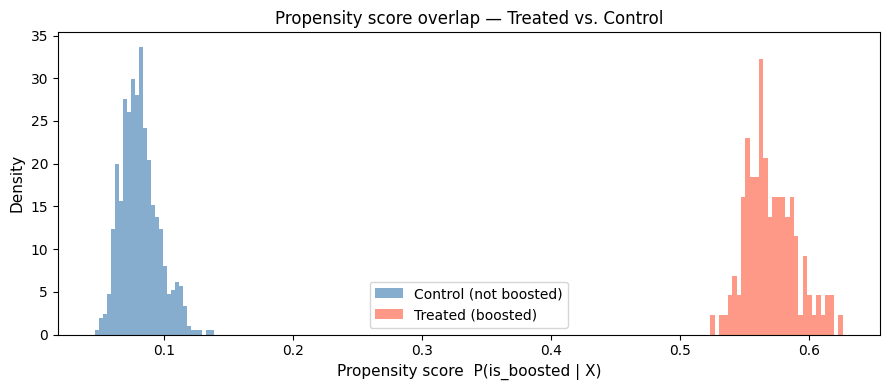

Propensity score range — control: [0.047, 0.139]
Propensity score range — treated: [0.523, 0.626]

Posts with propensity > 0.9 (extrapolation risk): 0
Posts with propensity < 0.1 (extrapolation risk): 613

Good overlap = both distributions span a similar propensity range.
If treated posts cluster near 1.0 and controls near 0.0, there is limited
common support and the T-Learner must extrapolate heavily.


In [8]:
# Phase 5 — Propensity score overlap (positivity / overlap check)
import matplotlib.pyplot as plt

prop_scores = propensity_pipeline.predict_proba(X)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prop_scores[T == 0], bins=30, alpha=0.65, label="Control (not boosted)", color="steelblue", density=True)
ax.hist(prop_scores[T == 1], bins=30, alpha=0.65, label="Treated (boosted)", color="tomato", density=True)
ax.set_xlabel("Propensity score  P(is_boosted | X)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Propensity score overlap — Treated vs. Control", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Propensity score range — control: [{prop_scores[T==0].min():.3f}, {prop_scores[T==0].max():.3f}]")
print(f"Propensity score range — treated: [{prop_scores[T==1].min():.3f}, {prop_scores[T==1].max():.3f}]")
print()
print(f"Posts with propensity > 0.9 (extrapolation risk): {(prop_scores > 0.9).sum()}")
print(f"Posts with propensity < 0.1 (extrapolation risk): {(prop_scores < 0.1).sum()}")
print()
print("Good overlap = both distributions span a similar propensity range.")
print("If treated posts cluster near 1.0 and controls near 0.0, there is limited")
print("common support and the T-Learner must extrapolate heavily.")

In [9]:
# Phase 5 — Covariate balance (SMD) and response surface AUC sanity check
from sklearn.metrics import roc_auc_score

print("=" * 65)
print("Covariate balance — Standardised Mean Difference (SMD, unadjusted)")
print("  |SMD| > 0.1 → potential confounding; > 0.25 → strong imbalance")
print("=" * 65)
print(f"{'Feature':<35} {'Treated mean':>14} {'Control mean':>14} {'SMD':>8}")
print("-" * 75)
for col in CAUSAL_NUMERIC_FEATURES:
    vals = df[col].values
    t_mean = vals[T == 1].mean()
    c_mean = vals[T == 0].mean()
    t_std  = vals[T == 1].std()
    c_std  = vals[T == 0].std()
    pooled = np.sqrt((t_std**2 + c_std**2) / 2) + 1e-9
    smd = (t_mean - c_mean) / pooled
    flag = " ◄" if abs(smd) > 0.1 else ""
    print(f"{col:<35} {t_mean:>14.3f} {c_mean:>14.3f} {smd:>+8.3f}{flag}")

print()
print("=" * 65)
print("Response surface AUC (in-sample — sanity check only, not causal validation)")
print("=" * 65)
auc_ctrl = roc_auc_score(Y[T == 0], control_pipeline.predict_proba(X[T == 0])[:, 1])
auc_trt  = roc_auc_score(Y[T == 1], treatment_pipeline.predict_proba(X[T == 1])[:, 1])
print(f"Control pipeline AUC on control posts:   {auc_ctrl:.4f}")
print(f"Treatment pipeline AUC on treated posts: {auc_trt:.4f}")
print()
print("AUC near 0.5 → response surface cannot distinguish outcomes within arm.")
print("High AUC → response surface is informative; ITE estimates have lower variance.")
print("(These are in-sample metrics — used only to validate that mu0 and mu1 are learnable.)")

Covariate balance — Standardised Mean Difference (SMD, unadjusted)
  |SMD| > 0.1 → potential confounding; > 0.25 → strong imbalance
Feature                               Treated mean   Control mean      SMD
---------------------------------------------------------------------------
caption_length                             136.512        137.469   -0.035
num_hashtags                                 2.205          2.018   +0.135 ◄
follower_count_at_post                    1415.748       1518.356   -0.147 ◄
post_hour                                   13.016         12.631   +0.062
has_call_to_action                           0.606          0.607   -0.002
boost_budget_php                          2430.144          0.000   +2.497 ◄

Response surface AUC (in-sample — sanity check only, not causal validation)
Control pipeline AUC on control posts:   0.9547
Treatment pipeline AUC on treated posts: 0.9646

AUC near 0.5 → response surface cannot distinguish outcomes within arm.
High AUC → resp

/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Phase 6 — Deployment

### Artifact format
The artifact saved in this phase is a Python `dict` containing three fitted sklearn
Pipelines and population-level ATE statistics:

```python
{
    "control_pipeline":    sklearn.Pipeline,  # mu0(X) = P(Y=1 | X, T=0)
    "treatment_pipeline":  sklearn.Pipeline,  # mu1(X) = P(Y=1 | X, T=1)
    "propensity_pipeline": sklearn.Pipeline,  # e(X)  = P(T=1 | X)
    "ate":       float,                       # population ATE (mean of ITE over all posts)
    "ate_lower": float,                       # 95% bootstrap CI lower bound
    "ate_upper": float,                       # 95% bootstrap CI upper bound
    "n_control": int,
    "n_treated": int,
}
```

### Inference at request time
For a new post with pre-treatment features X_new:
```
p_not_boosted = control_pipeline.predict_proba(X_new)[0, 1]    → P(gift | X, boost=0)
p_boosted     = treatment_pipeline.predict_proba(X_new)[0, 1]  → P(gift | X, boost=1)
ITE           = p_boosted - p_not_boosted                       → estimated lift
propensity    = propensity_pipeline.predict_proba(X_new)[0, 1]  → P(is_boosted | X)
```
The `ate`, `ate_lower`, `ate_upper` are constants from training, returned in every response.

### API integration
- **Artifact path:** `pipelines/social_causal_boost_pipeline_v1.sav`
- **Endpoint:** `POST /social/causal/predict`
- **Features endpoint:** `GET /social/causal/features`
- **Loaded by:** `app/services/social_causal.py` → `load_social_causal_artifact()`
- **Served by:** `app/routers/social_causal.py`

### Business decision this supports
"Given the planned content characteristics of a post (platform, topic, timing, CTA, etc.),
what is the estimated lift in donation referral probability from spending money to boost it?
Posts with a high estimated ITE and a moderate propensity score (e.g. 0.2–0.8) are the
best candidates for boosting ROI."

### Key assumption reminder
This estimate is valid only under **strong ignorability**: no unmeasured factors simultaneously
affect the boosting decision and the likelihood of a donation referral. This assumption cannot
be verified from observational data and should be communicated to any stakeholder using this output.

In [10]:
# Phase 6 — Save causal T-Learner artifact and smoke-test reload
import joblib
from pathlib import Path

_repo_out = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "pipelines").is_dir()),
    None,
)
if _repo_out is None:
    raise FileNotFoundError(
        "Could not find pipelines/ directory. "
        "Open Jupyter from the ml-pipelines root."
    )

artifact_path = _repo_out / "pipelines" / "social_causal_boost_pipeline_v1.sav"

artifact = {
    "control_pipeline":    control_pipeline,
    "treatment_pipeline":  treatment_pipeline,
    "propensity_pipeline": propensity_pipeline,
    "ate":       ate,
    "ate_lower": ate_lower,
    "ate_upper": ate_upper,
    "n_control": int((T == 0).sum()),
    "n_treated": int(T.sum()),
}

joblib.dump(artifact, artifact_path)
print(f"Saved to: {artifact_path}")

# Smoke-test: reload and verify structure
loaded = joblib.load(artifact_path)
required_keys = {"control_pipeline", "treatment_pipeline", "propensity_pipeline",
                 "ate", "ate_lower", "ate_upper", "n_control", "n_treated"}
assert set(loaded.keys()) == required_keys, f"Missing keys: {required_keys - loaded.keys()}"

# Smoke-test inference on first post
X_test = X.iloc[:1]
p0 = float(loaded["control_pipeline"].predict_proba(X_test)[0, 1])
p1 = float(loaded["treatment_pipeline"].predict_proba(X_test)[0, 1])
ps = float(loaded["propensity_pipeline"].predict_proba(X_test)[0, 1])
ite_test = p1 - p0

print()
print("Smoke-test inference (first post in dataset):")
print(f"  P(gift | not boosted): {p0:.4f}")
print(f"  P(gift | boosted):     {p1:.4f}")
print(f"  Estimated ITE:         {ite_test:+.4f}")
print(f"  Propensity score:      {ps:.4f}")
print()
print(f"Population ATE: {loaded['ate']:+.4f}")
print(f"95% Bootstrap CI: [{loaded['ate_lower']:+.4f}, {loaded['ate_upper']:+.4f}]")
print(f"n_control={loaded['n_control']}, n_treated={loaded['n_treated']}")
print()
print("API endpoint: POST /social/causal/predict")
print("Health check: GET /health  →  social_causal_artifact_loaded: true")

Saved to: /Users/gnelman/Documents/BYU/IS JUNIOR CORE/Winter 2026/Case Studies/INTEX II/Source Code/keeper/ml-pipelines/pipelines/social_causal_boost_pipeline_v1.sav

Smoke-test inference (first post in dataset):
  P(gift | not boosted): 0.7217
  P(gift | boosted):     0.9232
  Estimated ITE:         +0.2015
  Propensity score:      0.0704

Population ATE: +0.0860
95% Bootstrap CI: [-0.0294, +0.2020]
n_control=685, n_treated=127

API endpoint: POST /social/causal/predict
Health check: GET /health  →  social_causal_artifact_loaded: true


## Pipeline summary

| Item | Value |
|------|-------|
| **Notebook** | `social_media_causal_boost.ipynb` |
| **Method** | T-Learner (meta-learner causal inference) |
| **Data source** | `social_media_posts.csv` — 812 posts (single table, no joins) |
| **Treatment** | `is_boosted` (binary: 127 treated, 685 control) |
| **Outcome** | `has_referred_gift = (donation_referrals > 0)` (~64% positive) |
| **Features** | 13 pre-treatment covariates (6 numeric, 7 categorical) |
| **Artifact** | `pipelines/social_causal_boost_pipeline_v1.sav` |
| **API endpoint** | `POST /social/causal/predict` |

### ATE result
The population Average Treatment Effect (ATE) and its 95% bootstrap confidence interval
are printed in Phase 5 and Phase 6. Report these values here after running the notebook:

- **ATE:** *(run notebook to populate)*
- **95% CI:** *(run notebook to populate)*
- **Interpretation:** *(run notebook to populate — does CI exclude 0?)*

### Key assumption
This estimate assumes **strong ignorability**: conditional on the 13 observed pre-treatment
covariates, the potential outcomes `Y(0)` and `Y(1)` are independent of treatment assignment.
Equivalently, there are no unmeasured confounders that simultaneously influence the boosting
decision and the likelihood of a donation referral.

This assumption **cannot be verified** from observational data alone. The propensity score
overlap check (Phase 5) and SMD balance table (Phase 5) provide partial reassurance that
the treated and control groups are comparable on *observed* covariates, but unmeasured
factors (e.g. seasonal campaigns, staff intuition about post quality) may still confound
the estimate.

**Use this output to support, not replace, human judgment about boost spending decisions.**

### Contrast with the predictive social notebook
`social_media_engagement_increase.ipynb` is a purely predictive model that forecasts
engagement rate. It includes `is_boosted` as a covariate (for better conditional predictions)
but makes no causal claims. This notebook is the companion causal analysis that explicitly
estimates the *treatment effect* of boosting on donation referrals under stated assumptions.